In [166]:
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np
# Set Brian2 preferences
prefs.codegen.target = 'numpy'

In [319]:
"""
Implementation of Quadratic Integrate-and-Fire (QIF) network
from Dumont and Gutkin (2019) using Brian2
"""

start_scope()

# params (fig2. Dumont and Gutkin)

# Network size
Ne = Ni = 2000

# Time constants
tau_e = 10 * ms
tau_i = 10 * ms
tau_s = 1 * ms
tau_e_dim = tau_i_dim = 10

# Lorentzian distribution parameters
eta_mean_e = eta_mean_i = -5.0
Delta_e = Delta_i = 1

# Synaptic weights
Jee = 0.0
Jei = 15.0
Jie = 15.0
Jii = 0.0

Gee = 0.1
Gie = 0.5

# synaptic delay
d = 10*ms
# External input
Iext_e = 10
Iext_i = 0

# Threshold and reset
v_th = 50.0
v_r = -50.0
input_time = 0*ms

# Simulation duration
duration = 3000 * ms

# ============================================================
# NEURON MODEL EQUATIONS
# ============================================================

# Network 1 excitatory neurons
eqs_e1 = '''
dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
ds_ee/dt = -s_ee / tau_s : 1
ds_ei/dt = -s_ei / tau_s : 1
eta_e : 1
'''

# Network 1 inhibitory neurons
eqs_i1 = '''
dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
ds_ie/dt = -s_ie / tau_s : 1
ds_ii/dt = -s_ii / tau_s : 1
eta_i : 1
'''

# Network 1 excitatory neurons
eqs_e2 = '''
dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
ds_ee/dt = -s_ee / tau_s : 1
ds_ei/dt = -s_ei / tau_s : 1
eta_e : 1
'''

# Network 1 inhibitory neurons
eqs_i2 = '''
dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
ds_ie/dt = -s_ie / tau_s : 1
ds_ii/dt = -s_ii / tau_s : 1
eta_i : 1
'''

# CREATE NEURON GROUPS

E_neurons1 = NeuronGroup(Ne, eqs_e1, threshold='v > v_th', reset='v = v_r',
                        method='euler')
I_neurons1 = NeuronGroup(Ni, eqs_i1, threshold='v > v_th', reset='v = v_r',
                        method='euler')

E_neurons2 = NeuronGroup(Ne, eqs_e2, threshold='v > v_th', reset='v = v_r',
                        method='euler')

I_neurons2 = NeuronGroup(Ni, eqs_i2, threshold='v > v_th', reset='v = v_r',
                        method='euler')

# init heterogenous params
#initialize RANDOM for network 1
np.random.seed(42)
E_neurons1.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
I_neurons1.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i

# Initialize membrane potentials
E_neurons1.v = np.random.uniform(-1, 1, Ne)
I_neurons1.v = np.random.uniform(-1, 1, Ni)

# Initialize RANDOM for network 2
np.random.seed(43)
E_neurons2.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
I_neurons2.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i

# Initialize membrane potentials
E_neurons2.v = np.random.uniform(-1, 1, Ne)
I_neurons2.v = np.random.uniform(-1, 1, Ni)

# Initialize synaptic variables
E_neurons1.s_ee = 0
E_neurons1.s_ei = 0
I_neurons1.s_ie = 0
I_neurons1.s_ii = 0

E_neurons2.s_ee = 0
E_neurons2.s_ei = 0
I_neurons2.s_ie = 0
I_neurons2.s_ii = 0

# CREATE WITHIN-NETWORK SYNAPSES
#syn and s naming conventions are not consistent (too lazy to fix)
#POPULATION 1
# E -> E synapses
if Jee != 0:
    syn_ee1 = Synapses(E_neurons1, E_neurons1, on_pre='s_ee_post += Jee / Ne') 
    syn_ee1.connect()

# I -> E synapses (inhibition of excitatory population)
syn_ie1 = Synapses(I_neurons1, E_neurons1, on_pre='s_ei_post += Jei / Ni') 
syn_ie1.connect()

# E -> I synapses (excitation of inhibitory population)
syn_ei1 = Synapses(E_neurons1, I_neurons1, on_pre='s_ie_post += Jie / Ne ') 
syn_ei1.connect()
# I -> I synapses
if Jii != 0:
    syn_ii1 = Synapses(I_neurons1, I_neurons1, on_pre='s_ii_post += Jii / Ni') 
    syn_ii1.connect()
#==============
#POPULATION 2
# E -> E synapses
if Jee != 0:
    syn_ee2 = Synapses(E_neurons2, E_neurons2, on_pre='s_ee_post += Jee / Ne') 
    syn_ee2.connect()

# I -> E synapses (inhibition of excitatory population)
syn_ie2 = Synapses(I_neurons2, E_neurons2, on_pre='s_ei_post += Jei / Ni') 
syn_ie2.connect()

# E -> I synapses (excitation of inhibitory population)
syn_ei2 = Synapses(E_neurons2, I_neurons2, on_pre='s_ie_post += Jie / Ne ') 
syn_ei2.connect()

# I -> I synapses
if Jii != 0:
    syn_ii2 = Synapses(I_neurons2, I_neurons2, on_pre='s_ii_post += Jii / Ni') 
    syn_ii2.connect()

# ===================
# CREATE BETWEEN NETWORK SYNAPSES
#Population 1 to 2
# E -> E synapses
if Gee != 0:
    gsyn_ee1 = Synapses(E_neurons1, E_neurons2, on_pre = 's_ee_post += Gee / Ne', delay = d)
    gsyn_ee1.connect()

# E -> I synapses
if Gie != 0:
    gsyn_ei1 = Synapses(E_neurons1, I_neurons2, on_pre = 's_ie_post += Gie / Ne', delay = d)
    gsyn_ei1.connect()

#Population 2 to 1
# E -> E synapses
if Gee != 0:
    gsyn_ee2 = Synapses(E_neurons2, E_neurons1, on_pre = 's_ee_post += Gee / Ne', delay = d)
    gsyn_ee2.connect()
# E -> I synapses
if Gie != 0:
    gsyn_ei2 = Synapses(E_neurons2, I_neurons1, on_pre = 's_ie_post += Gie / Ne', delay = d)
    gsyn_ei2.connect()



# MONITORS
#population 1
spike_mon_e1 = SpikeMonitor(E_neurons1)
spike_mon_i1 = SpikeMonitor(I_neurons1)
rate_mon_e1 = PopulationRateMonitor(E_neurons1)
rate_mon_i1 = PopulationRateMonitor(I_neurons1)

q = 10
state_mon_e1 = StateMonitor(E_neurons1, ['v', 'I_total', 's_ee', 's_ei'], 
                           record=range(q))
state_mon_i1 = StateMonitor(I_neurons1, ['v', 'I_total', 's_ie', 's_ii'], 
                           record=range(q))

#population 2
spike_mon_e2 = SpikeMonitor(E_neurons2)
spike_mon_i2 = SpikeMonitor(I_neurons2)
rate_mon_e2 = PopulationRateMonitor(E_neurons2)
rate_mon_i2 = PopulationRateMonitor(I_neurons2)

q = 10
state_mon_e2 = StateMonitor(E_neurons2, ['v', 'I_total', 's_ee', 's_ei'], 
                           record=range(q))
state_mon_i2 = StateMonitor(I_neurons2, ['v', 'I_total', 's_ie', 's_ii'], 
                           record=range(q))

# RUN SIM

print("Running simulation...")
run(duration)
print("Simulation complete!")

Running simulation...
Simulation complete!


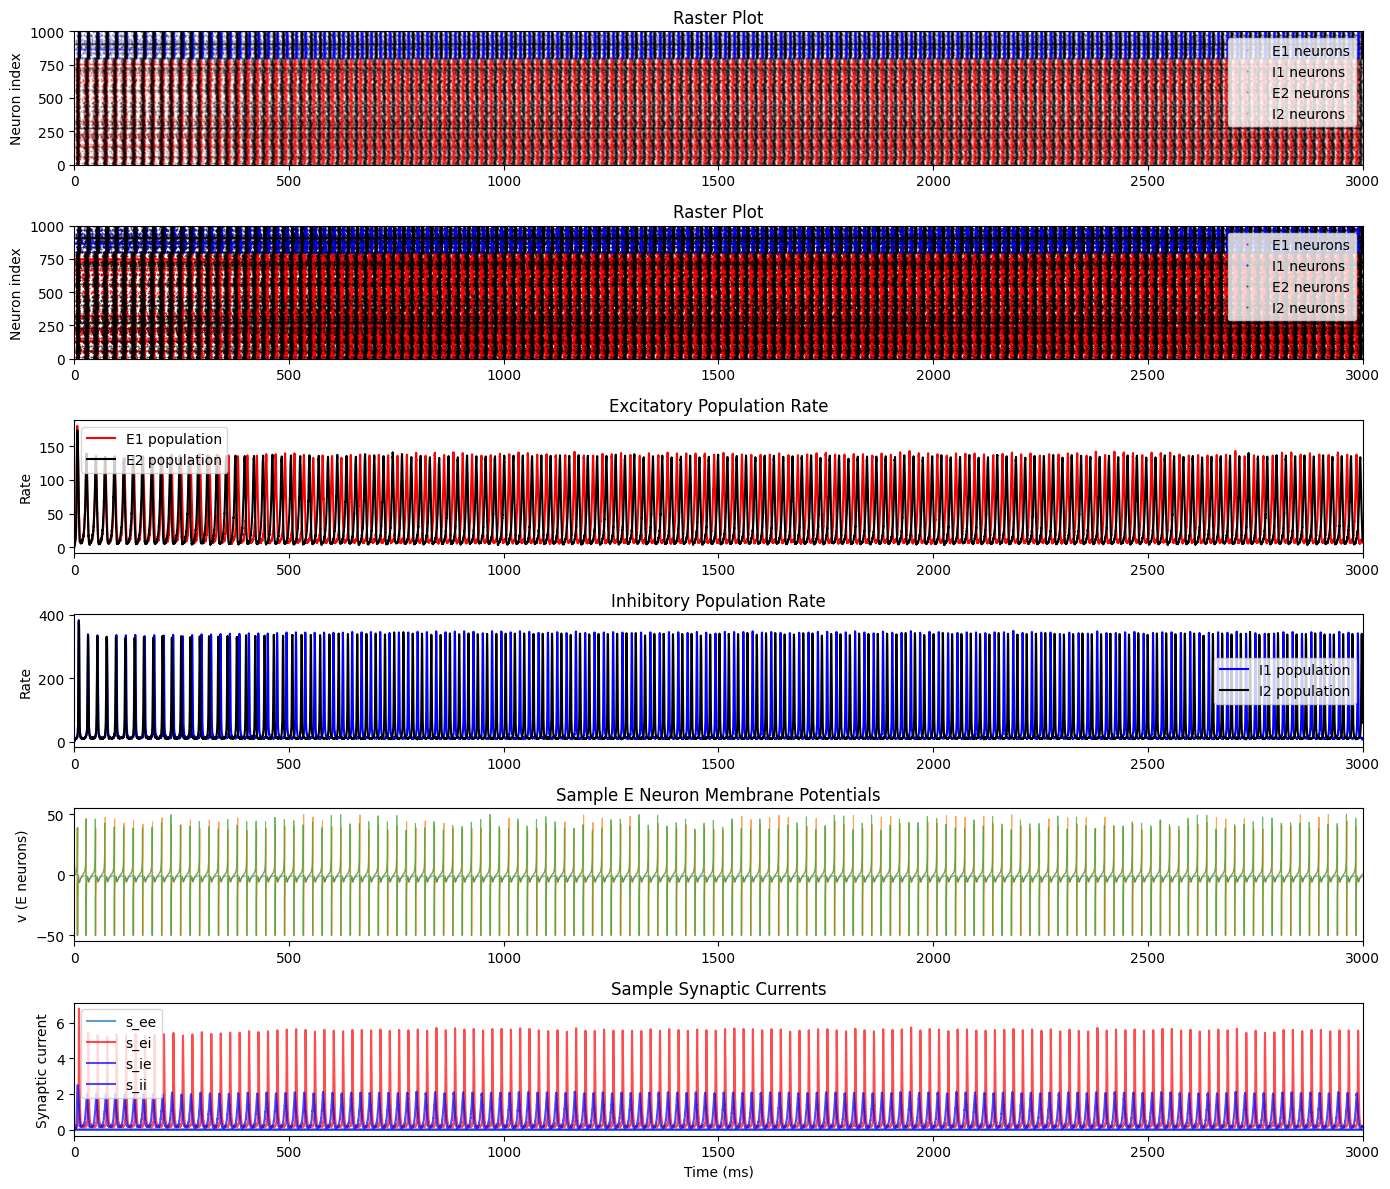


Network Statistics:
Total E spikes: 250463
Total I spikes: 311643
Mean E rate: 41.74 Hz
Mean I rate: 51.94 Hz


In [320]:
# PLOTS

fig, axes = plt.subplots(6, 1, figsize=(14, 12))

# Plot 1: Raster plot
ax1 = axes[0]
n_e_sample = 800
n_i_sample = 200  # Should match Ni if you want all inhibitory neurons

#index masks
e_mask1 = spike_mon_e1.i < n_e_sample
i_mask1 = spike_mon_i1.i < n_i_sample

e_mask2 = spike_mon_e2.i < n_e_sample
i_mask2 = spike_mon_i2.i < n_i_sample

# Network 1
ax1.plot(spike_mon_e1.t[e_mask1]/ms, spike_mon_e1.i[e_mask1], '.r', 
         markersize=1, label='E1 neurons', alpha = 0.3)
ax1.plot(spike_mon_i1.t[i_mask1]/ms, spike_mon_i1.i[i_mask1] + n_e_sample, '.b', 
         markersize=1, label='I1 neurons', alpha = 0.3)

# Network 2
ax1.plot(spike_mon_e2.t[e_mask2]/ms, spike_mon_e2.i[e_mask2], '.k', 
         markersize=1, label='E2 neurons', alpha=0.3)
ax1.plot(spike_mon_i2.t[i_mask2]/ms, spike_mon_i2.i[i_mask2] + n_e_sample, '.k', 
         markersize=1, label='I2 neurons', alpha=0.3)

ax1.set_ylabel('Neuron index')
ax1.set_title('Raster Plot')
ax1.legend(loc='upper right')
ax1.set_xlim(0, duration/ms)
ax1.set_ylim(0, n_e_sample + n_i_sample)  # Add this line to set proper y-limits


#plot full raster
ax6=axes[1]
# Network 1
ax6.plot(spike_mon_e1.t[e_mask1]/ms, spike_mon_e1.i[e_mask1], '.r', 
         markersize=1, label='E1 neurons')
ax6.plot(spike_mon_i1.t[i_mask1]/ms, spike_mon_i1.i[i_mask1] + n_e_sample, '.b', 
         markersize=1, label='I1 neurons')

# Network 2
ax6.plot(spike_mon_e2.t[e_mask2]/ms, spike_mon_e2.i[e_mask2], '.k', 
         markersize=1, label='E2 neurons', alpha=0.7)
ax6.plot(spike_mon_i2.t[i_mask2]/ms, spike_mon_i2.i[i_mask2] + n_e_sample, '.k', 
         markersize=1, label='I2 neurons', alpha=0.7)

ax6.set_ylabel('Neuron index')
ax6.set_title('Raster Plot')
ax6.legend(loc='upper right')
ax6.set_xlim(0, duration/ms)
ax6.set_ylim(0, n_e_sample + n_i_sample)  # Add this line to set proper y-limits

# Plot 2 & 3: Population firing rates
#population 1
ax2 = axes[2]
ax2.plot(rate_mon_e1.t/ms, rate_mon_e1.smooth_rate(window='flat', width=2*ms)/Hz, 
         'r', label='E1 population')
#population 2
ax2.plot(rate_mon_e2.t/ms, rate_mon_e2.smooth_rate(window='flat', width=2*ms)/Hz, 
         'k', label='E2 population')
ax2.set_ylabel('Rate')
ax2.set_title('Excitatory Population Rate')
ax2.legend()
ax2.set_xlim(0, duration/ms)

ax3 = axes[3]
ax3.plot(rate_mon_i1.t/ms, rate_mon_i1.smooth_rate(window='flat', width=2*ms)/Hz, 
         'b', label='I1 population')
ax3.plot(rate_mon_i2.t/ms, rate_mon_i2.smooth_rate(window='flat', width=2*ms)/Hz, 
         'k', label='I2 population')
ax3.set_ylabel('Rate')
ax3.set_title('Inhibitory Population Rate')
ax3.legend()
ax3.set_xlim(0, duration/ms)

# Plot 4: Sample membrane potentials
ax4 = axes[4]
for idx in range(min(3, q)):
    ax4.plot(state_mon_e1.t/ms, state_mon_e1.v[idx], alpha=0.7, linewidth=0.8)
ax4.set_ylabel('v (E neurons)')
ax4.set_title('Sample E Neuron Membrane Potentials')
ax4.set_xlim(0, duration/ms)

# Plot 5: Synaptic currents
ax5 = axes[5]
ax5.plot(state_mon_e1.t/ms, state_mon_e1.s_ee[0], label='s_ee', alpha=0.7)
ax5.plot(state_mon_e1.t/ms, state_mon_e1.s_ei[0],'r', label='s_ei', alpha=0.7)
ax5.plot(state_mon_i1.t/ms, state_mon_i1.s_ie[0],'b', label='s_ie', alpha=0.7)
ax5.plot(state_mon_i1.t/ms, state_mon_i1.s_ii[0],'b', label='s_ii', alpha=0.7)
ax5.set_ylabel('Synaptic current')
ax5.set_xlabel('Time (ms)')
ax5.set_title('Sample Synaptic Currents')
ax5.legend()
ax5.set_xlim(0, duration/ms)

plt.tight_layout()
plt.show()

print("\nNetwork Statistics:")
print(f"Total E spikes: {len(spike_mon_e1.t)}")
print(f"Total I spikes: {len(spike_mon_i1.t)}")
if duration > 0*second:
    print(f"Mean E rate: {len(spike_mon_e1.t) / (Ne * duration/second):.2f} Hz")
    print(f"Mean I rate: {len(spike_mon_i1.t) / (Ni * duration/second):.2f} Hz")

https://stackoverflow.com/questions/27545171/identifying-phase-shift-between-signals
1. cross-correlation: average phase lag for the entire recording. Best once the coupling reaches steady state.
2. frequency domain: calculate the angle between frequencies of interest; phase lag is radians by calculating angle of fft applied to signal(bin)
3. hilbert transform: converts time domain signal into analytic signal which is a vector of complex numbers. Allows to get instantaneous phase lag between two signals as long as the signal of interest dominates the recording

In [307]:
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import welch

Network 1 frequency: 39.06 Hz
Network 2 frequency: 39.06 Hz
Frequency difference: 0.000 Hz
Phase Difference Mean -2.6183529188388994


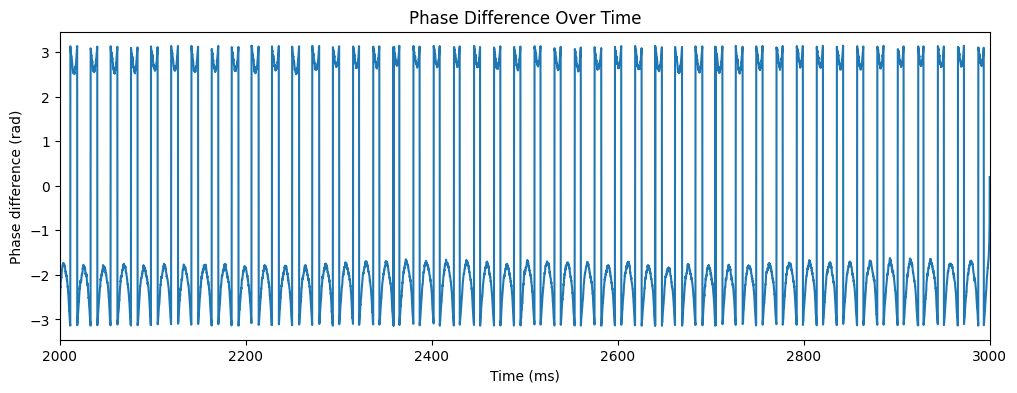

In [321]:
# analyze frequency and phase drift

# Remove transient
transient_time = 2000*ms
start_idx = int(transient_time / defaultclock.dt)

rate_e1 = rate_mon_e1.smooth_rate(window='flat', width=2*ms)/Hz
rate_e2 = rate_mon_e2.smooth_rate(window='flat', width=2*ms)/Hz

rate_e1_steady = rate_e1[start_idx:]
rate_e2_steady = rate_e2[start_idx:]
time_steady = rate_mon_e1.t[start_idx:]/ms

# Check frequencies
f1, psd1 = welch(rate_e1_steady, fs=1000/defaultclock.dt*ms, nperseg=min(256, len(rate_e1_steady)//4))
f2, psd2 = welch(rate_e2_steady, fs=1000/defaultclock.dt*ms, nperseg=min(256, len(rate_e2_steady)//4))

peak_freq_1 = f1[np.argmax(psd1)]
peak_freq_2 = f2[np.argmax(psd2)]

print(f"Network 1 frequency: {peak_freq_1:.2f} Hz")
print(f"Network 2 frequency: {peak_freq_2:.2f} Hz")
print(f"Frequency difference: {abs(peak_freq_1 - peak_freq_2):.3f} Hz")

# Check phase drift over time
from scipy.signal import hilbert

analytic_1 = hilbert(rate_e1_steady - np.mean(rate_e1_steady))
analytic_2 = hilbert(rate_e2_steady - np.mean(rate_e2_steady))

phase_diff = np.angle(analytic_2 / analytic_1)
mean_phase_diff = np.angle(np.mean(np.exp(1j * phase_diff)))
phase_diff = np.angle((np.exp(1j * phase_diff)))
print(f"Phase Difference Mean {mean_phase_diff}")
# Convert to time lag (using mean frequency)

# Plot phase difference over time
plt.figure(figsize=(12, 4))
plt.plot(time_steady, phase_diff)
plt.xlabel('Time (ms)')
plt.ylabel('Phase difference (rad)')
plt.title('Phase Difference Over Time')
plt.xlim(transient_time/ms, duration/ms)
plt.show()

# If phase difference has a linear trend, networks are drifting
# If it's flat (with noise), they're locked
# Large delays should show anti phase locking (phase diff should jump between +- some value)

In [309]:
from scipy.signal import correlate
# discard transient in order to let the networks settle into steady phase-locking
transient_time = 300*ms #phase lag seems to just increase as this increases for xcor; for hilbert after ~200ms the estimate seems robust but very wrong, see below for idea
start_idx = int(transient_time / defaultclock.dt)
rate_e1 = rate_mon_e1.smooth_rate(window='flat', width=2*ms)/Hz
rate_e2 = rate_mon_e2.smooth_rate(window='flat', width=2*ms)/Hz

# Get smoothed rates after transient
rate_e1_steady = rate_e1[start_idx:]
rate_e2_steady = rate_e2[start_idx:]
time_steady = rate_mon_e1.t[start_idx:] / ms

# Find peaks
peaks_1, _ = find_peaks(rate_e1_steady, prominence=50)  # Adjust prominence
peaks_2, _ = find_peaks(rate_e2_steady, prominence=50)

# Get peak times; times where peaks occur only
peak_times_1 = time_steady[peaks_1]
peak_times_2 = time_steady[peaks_2]

# For each peak in network 1, find closest peak in network 2
#this likely won't work if the lag just gets bigger and bigger, if one signal goes from leader to follower then closest idx doesnt detect this change; unstable regime?
lags = []
for t1 in peak_times_1:
    closest_idx = np.argmin(np.abs(peak_times_2 - t1))
    lag = peak_times_2[closest_idx] - t1
    lags.append(lag)

mean_lag = np.mean(lags)
std_lag = np.std(lags)

print(f"Mean Peak lag: {mean_lag:.2f} ± {std_lag:.2f} ms")

# ===
# the lag of the maximum of the cross-correlation corresponds to the signal delay between the two signals
# ===
# XCOR

# cross-correlation
correlation = signal.correlate(rate_e1_steady, rate_e2_steady, mode='full') #full returns the full convolution of the two signals
lags_samples = signal.correlation_lags(len(rate_e1_steady), len(rate_e2_steady), mode='full') #lag/indices
lags_ms = lags_samples * defaultclock.dt / ms #get lags into correct time scale

# get lag at maximum correlation
max_corr_idx = np.argmax(correlation)
phase_lag = lags_ms[max_corr_idx]

print(f"xCor Estimated phase lag: {phase_lag:.2f} ms")

#=======
#Hilbert Transform

# Compute analytic signal and instantaneous phase
analytic_signal_1 = signal.hilbert(rate_e1_steady - np.mean(rate_e1_steady))
analytic_signal_2 = signal.hilbert(rate_e2_steady - np.mean(rate_e2_steady))

# Phase difference
phase_diff = np.angle(analytic_signal_2 / analytic_signal_1)
# Convert to time lag (using mean frequency)
mean_phase_diff = np.angle(np.mean(np.exp(1j * phase_diff))) #circular mean
# Estimate oscillation period from rate monitor
fft_freq = np.fft.rfftfreq(len(rate_e1_steady), defaultclock.dt/second)
fft_power = np.abs(np.fft.rfft(rate_e1_steady))
dominant_freq = fft_freq[np.argmax(fft_power[1:])+1]  # Skip DC
period = 1/dominant_freq
time_lag = (mean_phase_diff / (2*np.pi)) * period * 1000  # in ms


print(f"Hilbert mean phase difference: {mean_phase_diff:.3f} rad")
print(f"Hilbert time lag: {time_lag:.2f} ms")

Mean Peak lag: -0.47 ± 6.01 ms
xCor Estimated phase lag: -16.10 ms
Hilbert mean phase difference: 0.813 rad
Hilbert time lag: 2.96 ms


Observations:
Hilbert method seems quite bad (only works 'well' for long run durations) (fixed). 
There doesn't seem to be any phase locking since the lags seem to keep increasing as time goes on. In other words no transient captures a true steady state. 

In [342]:
# ===
# the lag of the maximum of the cross-correlation corresponds to the signal delay between the two signals
# ===
# XCOR

def run_coupled_network(delay_val, Gee, Gie, duration = 500 * ms, Ne=2000, Ni=2000):
    start_scope()

    tau_e = 10 * ms
    tau_i = 10 * ms
    tau_s = 1 * ms
    tau_e_dim = tau_i_dim = 10

    # Lorentzian distribution parameters
    eta_mean_e = eta_mean_i = -5.0
    Delta_e = Delta_i = 1

    # Synaptic weights
    Jee = 0.0
    Jei = 15.0
    Jie = 15.0
    Jii = 0.0


    # synaptic delay
    d = delay_val*ms

    # External input
    Iext_e = 10
    Iext_i = 0

    # Threshold and reset; default clock; 0.1ms for 50; 0.01 for 500
    defaultclock.dt = 0.01*ms
    v_th = 500.0
    v_r = -500.0
    input_time = 0*ms

    # Simulation duration
    # duration = 500 * ms

    # ============================================================
    # NEURON MODEL EQUATIONS
    # ============================================================

    # Network 1 excitatory neurons
    eqs_e1 = '''
    dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
    I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
    ds_ee/dt = -s_ee / tau_s : 1
    ds_ei/dt = -s_ei / tau_s : 1
    eta_e : 1
    '''

    # Network 1 inhibitory neurons
    eqs_i1 = '''
    dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
    I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
    ds_ie/dt = -s_ie / tau_s : 1
    ds_ii/dt = -s_ii / tau_s : 1
    eta_i : 1
    '''

    # Network 1 excitatory neurons
    eqs_e2 = '''
    dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
    I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
    ds_ee/dt = -s_ee / tau_s : 1
    ds_ei/dt = -s_ei / tau_s : 1
    eta_e : 1
    '''

    # Network 1 inhibitory neurons
    eqs_i2 = '''
    dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
    I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
    ds_ie/dt = -s_ie / tau_s : 1
    ds_ii/dt = -s_ii / tau_s : 1
    eta_i : 1
    '''


    # CREATE NEURON GROUPS

    E_neurons1 = NeuronGroup(Ne, eqs_e1, threshold='v > v_th', reset='v = v_r',
                            method='euler')
    I_neurons1 = NeuronGroup(Ni, eqs_i1, threshold='v > v_th', reset='v = v_r',
                            method='euler')

    E_neurons2 = NeuronGroup(Ne, eqs_e2, threshold='v > v_th', reset='v = v_r',
                            method='euler')

    I_neurons2 = NeuronGroup(Ni, eqs_i2, threshold='v > v_th', reset='v = v_r',
                            method='euler')

    # init heterogenous params
    #initialize for network 1
    np.random.seed(42)
    E_neurons1.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
    I_neurons1.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i

    # Initialize membrane potentials
    E_neurons1.v = np.random.uniform(-1, 1, Ne)
    I_neurons1.v = np.random.uniform(-1, 1, Ni)

    # Initialize for network 2
    E_neurons2.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
    I_neurons2.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i

    # Initialize membrane potentials
    E_neurons2.v = np.random.uniform(-1, 1, Ne)
    I_neurons2.v = np.random.uniform(-1, 1, Ni)

    # Initialize synaptic variables
    E_neurons1.s_ee = 0
    E_neurons1.s_ei = 0
    I_neurons1.s_ie = 0
    I_neurons1.s_ii = 0

    E_neurons2.s_ee = 0
    E_neurons2.s_ei = 0
    I_neurons2.s_ie = 0
    I_neurons2.s_ii = 0

    # CREATE WITHIN-NETWORK SYNAPSES
    #syn and s naming conventions are not consistent (too lazy to fix)
    #POPULATION 1
    # E -> E synapses
    if Jee != 0:
        syn_ee1 = Synapses(E_neurons1, E_neurons1, on_pre='s_ee_post += Jee / Ne')
        syn_ee1.connect()

    # I -> E synapses (inhibition of excitatory population)
    syn_ie1 = Synapses(I_neurons1, E_neurons1, on_pre='s_ei_post += Jei / Ni')
    syn_ie1.connect()

    # E -> I synapses (excitation of inhibitory population)
    syn_ei1 = Synapses(E_neurons1, I_neurons1, on_pre='s_ie_post += Jie / Ne ')
    syn_ei1.connect()
    # I -> I synapses
    if Jii != 0:
        syn_ii1 = Synapses(I_neurons1, I_neurons1, on_pre='s_ii_post += Jii / Ni')
        syn_ii1.connect()
    #==============
    #POPULATION 2
    # E -> E synapses
    if Jee != 0:
        syn_ee2 = Synapses(E_neurons2, E_neurons2, on_pre='s_ee_post += Jee / Ne')
        syn_ee2.connect()

    # I -> E synapses (inhibition of excitatory population)
    syn_ie2 = Synapses(I_neurons2, E_neurons2, on_pre='s_ei_post += Jei / Ni')
    syn_ie2.connect()

    # E -> I synapses (excitation of inhibitory population)
    syn_ei2 = Synapses(E_neurons2, I_neurons2, on_pre='s_ie_post += Jie / Ne ')
    syn_ei2.connect()

    # I -> I synapses
    if Jii != 0:
        syn_ii2 = Synapses(I_neurons2, I_neurons2, on_pre='s_ii_post += Jii / Ni')
        syn_ii2.connect()

    # ===================
    # CREATE BETWEEN NETWORK SYNAPSES
    #Population 1 to 2
    # E -> E synapses
    if Gee != 0:
        gsyn_ee1 = Synapses(E_neurons1, E_neurons2, on_pre = 's_ee_post += Gee / Ne', delay = d)
        gsyn_ee1.connect()

    # E -> I synapses
    if Gie != 0:
        gsyn_ei1 = Synapses(E_neurons1, I_neurons2, on_pre = 's_ie_post += Gie / Ne', delay = d)
        gsyn_ei1.connect()

    #Population 2 to 1
    # E -> E synapses
    if Gee != 0:
        gsyn_ee2 = Synapses(E_neurons2, E_neurons1, on_pre = 's_ee_post += Gee / Ne', delay = d)
        gsyn_ee2.connect()
    # E -> I synapses
    if Gie != 0:
        gsyn_ei2 = Synapses(E_neurons2, I_neurons1, on_pre = 's_ie_post += Gie / Ne', delay = d)
        gsyn_ei2.connect()


    rate_mon_e1 = PopulationRateMonitor(E_neurons1)
    #rate_mon_i1 = PopulationRateMonitor(I_neurons1)

    rate_mon_e2 = PopulationRateMonitor(E_neurons2)
    #rate_mon_i2 = PopulationRateMonitor(I_neurons2)


    run(duration)
    return rate_mon_e1, rate_mon_e2

from scipy import signal

In [343]:
def get_network_phase_lag(rate_mon1, rate_mon2, transient_time = 300*ms):
    start_idx = int(transient_time / defaultclock.dt)
    rate_e1 = rate_mon1.smooth_rate(window='flat', width=2*ms)/Hz
    rate_e2 = rate_mon2.smooth_rate(window='flat', width=2*ms)/Hz

    # Get smoothed rates after transient
    rate_e1_steady = rate_e1[start_idx:]
    rate_e2_steady = rate_e2[start_idx:]
    
    #Hilbert Transform
    # Compute analytic signal and instantaneous phase
    analytic_signal_1 = signal.hilbert(rate_e1_steady - np.mean(rate_e1_steady))
    analytic_signal_2 = signal.hilbert(rate_e2_steady - np.mean(rate_e2_steady))

    # Phase difference
    phase_diff = np.angle(analytic_signal_2 / analytic_signal_1)
    # circular mean in radians [-pi, pi]
    mean_phase_diff = np.angle(np.mean(np.exp(1j * phase_diff))) #circular mean
    
    # convert to [0, 2pi]
    phase_lag = mean_phase_diff
    phase_lag = mean_phase_diff % (2 * np.pi)
    return phase_lag



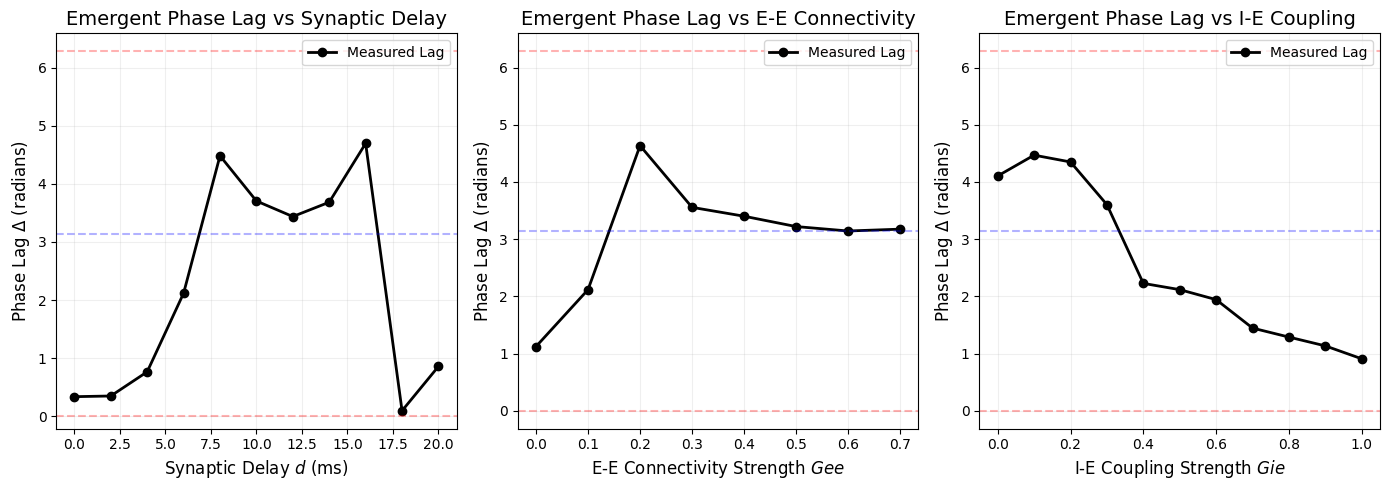

In [331]:
#this was run with defaultclock = 0.1ms, threshold/reset = +-50
duration = 10000*ms
transient_time = 2000*ms
num_neurons = 2000 #*2
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
ax1=axes[0]; ax2=axes[1]; ax3=axes[2]

#phase lag vs delay
delay_range = np.arange(0, 21, 2)

d_measured_lags = []

for d_val in delay_range:
  rm1, rm2 = run_coupled_network(delay_val=d_val, Gee=0.1, Gie=0.5, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  d_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax1.plot(delay_range, d_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax1.axhline(np.pi, color='blue', linestyle='--', alpha=0.3)
ax1.axhline(2*np.pi, color='red', linestyle='--', alpha=0.3)
ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Synaptic Delay $d$ (ms)', fontsize=12)
ax1.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax1.set_title('Emergent Phase Lag vs Synaptic Delay', fontsize=14)
ax1.grid(True, alpha=0.2)
ax1.legend()

#phase lag vs Gee
Gee_range = np.arange(0, 0.8, 0.1)
gee_measured_lags = []
for Gee_val in Gee_range:
  rm1, rm2 = run_coupled_network(delay_val=6, Gee=Gee_val, Gie=0.5, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  gee_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax2.plot(Gee_range, gee_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax2.axhline(np.pi, color='blue', linestyle='--', alpha=0.3)
ax2.axhline(2*np.pi, color='red', linestyle='--', alpha=0.3)
ax2.axhline(0, color='red', linestyle='--', alpha=0.3)
ax2.set_xlabel('E-E Connectivity Strength $Gee$', fontsize=12)
ax2.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax2.set_title('Emergent Phase Lag vs E-E Connectivity', fontsize=14)
ax2.grid(True, alpha=0.2)
ax2.legend()


#phase lag vs Gie
Gie_range = np.arange(0.0, 1.1, 0.1)
gie_measured_lags = []
for Gie_val in Gie_range:
  rm1, rm2 = run_coupled_network(delay_val=6, Gee=0.1, Gie=Gie_val, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  gie_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax3.plot(Gie_range, gie_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax3.axhline(np.pi, color='blue', linestyle='--', alpha=0.3)
ax3.axhline(2*np.pi, color='red', linestyle='--', alpha=0.3)
ax3.axhline(0, color='red', linestyle='--', alpha=0.3)
ax3.set_xlabel('I-E Coupling Strength $Gie$', fontsize=12)
ax3.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax3.set_title('Emergent Phase Lag vs I-E Coupling', fontsize=14)
ax3.grid(True, alpha=0.2)
ax3.legend()

plt.tight_layout()
plt.show() 

These graphs were attempts to reproduce the bifurcation diagrams shown in figure 6 of the Dumont and Gutkin paper.

For synaptic delay, the plot suggests that for short and long delays the network produces in-phase oscillations, while for an intermediate range the network produces anti-phase oscillations. However if we look at the raster plots associated with specific delay values it is obvious that for short and long delays we are in a leader/follower regime biased towards in-phase oscillations. For d=12 it might be that we are approaching a value near some bifuraction that would result in anti-phase oscillations. Alternatively it could be that this value simply results in a leader/follower regime with high period such that the simulation could not accurately estimate the phase lag. 

Our simulations differ from Dumont and Gutkin by the number of neurons used and a different spiking values. It could be that these simulations are not using enough neurons which results in slower convergence. We could not feasibly produce these graphs with larger populations. Alternatively, changing the reset/threshold values without changing all the other related parameters might have also changed where we are in parameter space. As a result, we are not close enough to a limit cycle regime (hop bifurcation?) that produces the effects as seen in Dumont and Gutkin.

For coupling strength parameters Gie and Gee, we can see some similar effects as described by Dumont and Gutkin. Increasing E-E leads to a bifurcation resultling in anti-phase oscillations. We find that before this point the phase is neither strongly in or out of phase. Here there is leader follower dynamics. For I-E coupling, the dynamics go from leader follower to in-phase oscillations. Both of these effects are clearly continuous are reflective of some sort of bifurcation. For coupling values near 0, Dumont and Gutkin report clear in-phase/anti-phase oscillations (respectively), however our simulations do not produce these. 

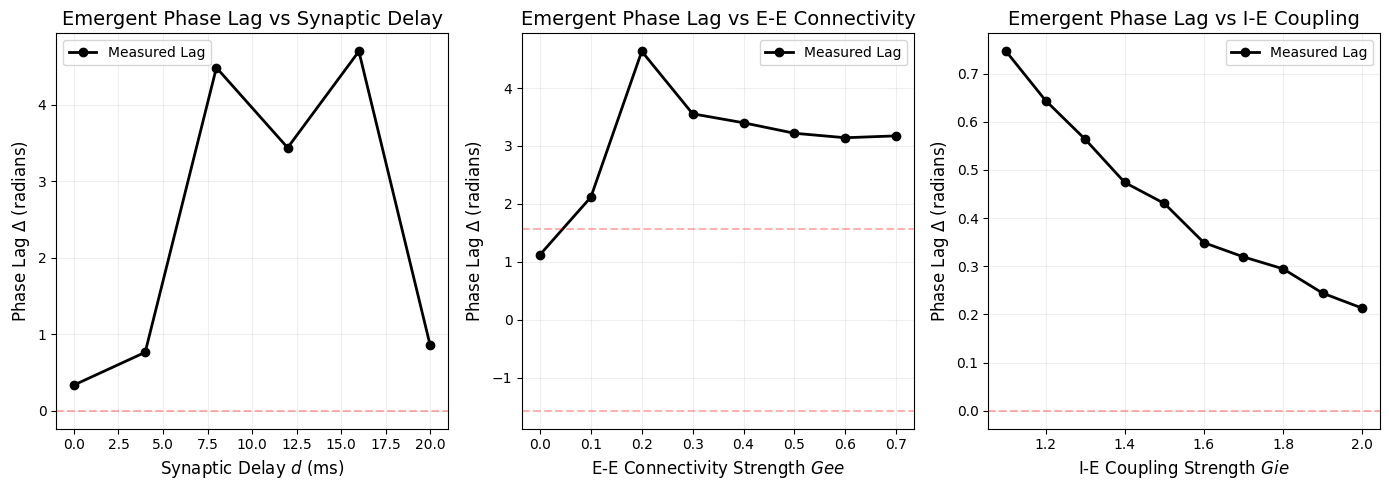

In [332]:
#this was run with defaultclock = 0.1ms, threshold/reset = +-50
duration = 10000*ms
transient_time = 2000*ms
num_neurons = 2000 #*2
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
ax1=axes[0]; ax2=axes[1]; ax3=axes[2]

#phase lag vs delay
delay_range = np.arange(0, 21, 4)

d2_measured_lags = []

for d_val in delay_range:
  rm1, rm2 = run_coupled_network(delay_val=d_val, Gee=0.1, Gie=0.5, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  d2_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax1.plot(delay_range, d2_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Synaptic Delay $d$ (ms)', fontsize=12)
ax1.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax1.set_title('Emergent Phase Lag vs Synaptic Delay', fontsize=14)
ax1.grid(True, alpha=0.2)
ax1.legend()

#phase lag vs Gee
Gee_range = np.arange(0, 0.8, 0.1)
gee2_measured_lags = []
for Gee_val in Gee_range:
  rm1, rm2 = run_coupled_network(delay_val=6, Gee=Gee_val, Gie=0.5, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  gee2_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax2.plot(Gee_range, gee2_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax2.axhline(np.pi/2, color='red', linestyle='--', alpha=0.3)
ax2.axhline(-np.pi/2, color='red', linestyle='--', alpha=0.3)
ax2.set_xlabel('E-E Connectivity Strength $Gee$', fontsize=12)
ax2.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax2.set_title('Emergent Phase Lag vs E-E Connectivity', fontsize=14)
ax2.grid(True, alpha=0.2)
ax2.legend()


#phase lag vs Gie
Gie_range = np.arange(1.1, 2.1, 0.1)
gie2_measured_lags = []
for Gie_val in Gie_range:
  rm1, rm2 = run_coupled_network(delay_val=6, Gee=0.1, Gie=Gie_val, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  gie2_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax3.plot(Gie_range, gie2_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax3.axhline(0, color='red', linestyle='--', alpha=0.3)
ax3.set_xlabel('I-E Coupling Strength $Gie$', fontsize=12)
ax3.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax3.set_title('Emergent Phase Lag vs I-E Coupling', fontsize=14)
ax3.grid(True, alpha=0.2)
ax3.legend()

plt.tight_layout()
plt.show() 

missing: motivate the project
-what are we trying to do; what is the research question the paper is trying to address
    -communication through coherence hypothesis; how well does a network communicate with another

-incorporation ideas about bifurcations parameters

-add slide numbers to each slide

slide 1: we don't need to introduce ourselves; 
add motivation here
slide 2: network description; cut equations expect for Lorentzian distribution; cut synaptic equations, just use the picture
dont mention the thing about Lorenztian distributions and intrinsic oscillators 
slide 3: PING Network: explain why oscillations occur 
    -share that the paper also explored ing oscillations
    -add time (ms) to plots
    -make plots bigger
    -reference the PING figure (Dumont and Gutkin 2019)
slide 4: Exploring Effects of External Currents ext
    -explain oscillation coherence; Quantiifies how prominent the peak in the power spectrum is
side 5: reduce power spectrum or remove
slide 6?: Exploring external currents inhib
    -if this is kept; change the coherence plot to match the x range of slide 4 coherence plot
    -add firing rate
    -remove peak frequency
slide: coupled network
    -show comparison between our results and paper
    -don't use the word jump; explain that it is a continuous change (bifucations are continuous)
    -


The above plot was made to test whether the number of neurons were effecting the results. This graph is nearly identical to the previous phase lag vs delay plot however it uses 5000 neurons (as opposed to 2000) and different values d are sampled. Since d=12 was not sampled here, a simulation was run independently and the dip toward $\pi$ still occurs. The raster plots still show that we are in a leader follower regime and not in oscillating in/out of phase.

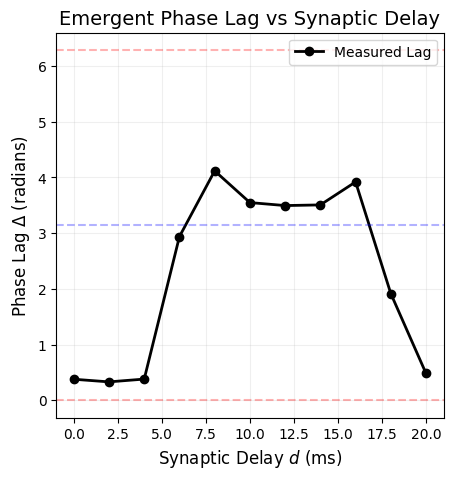

In [351]:
#this was run with defaultclock = 0.01ms, reset/threshold = +-500
duration = 5000*ms
transient_time = 2000*ms
num_neurons = 2000 #*2
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
ax1=axes

#phase lag vs delay
delay_range = np.arange(0, 21, 2)

d_measured_lags = []

for d_val in delay_range:
  rm1, rm2 = run_coupled_network(delay_val=d_val, Gee=0.1, Gie=0.5, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  d_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax1.plot(delay_range, d_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax1.axhline(np.pi, color='blue', linestyle='--', alpha=0.3)
ax1.axhline(2*np.pi, color='red', linestyle='--', alpha=0.3)
ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Synaptic Delay $d$ (ms)', fontsize=12)
ax1.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax1.set_title('Emergent Phase Lag vs Synaptic Delay', fontsize=14)
ax1.grid(True, alpha=0.2)
ax1.legend()

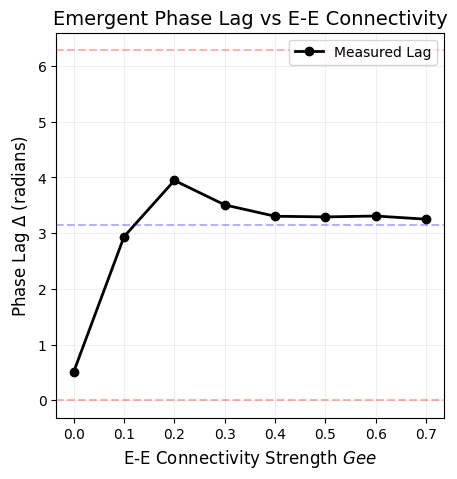

In [352]:
#this was run with defaultclock = 0.01ms, reset/threshold = +-500
#phase lag vs Gee
duration = 5000*ms
transient_time = 2000*ms
num_neurons = 2000 #*2
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
ax2=axes

Gee_range = np.arange(0, 0.8, 0.1)
gee_measured_lags = []
for Gee_val in Gee_range:
  rm1, rm2 = run_coupled_network(delay_val=6, Gee=Gee_val, Gie=0.5, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  gee_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax2.plot(Gee_range, gee_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax2.axhline(np.pi, color='blue', linestyle='--', alpha=0.3)
ax2.axhline(2*np.pi, color='red', linestyle='--', alpha=0.3)
ax2.axhline(0, color='red', linestyle='--', alpha=0.3)
ax2.set_xlabel('E-E Connectivity Strength $Gee$', fontsize=12)
ax2.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax2.set_title('Emergent Phase Lag vs E-E Connectivity', fontsize=14)
ax2.grid(True, alpha=0.2)
ax2.legend()

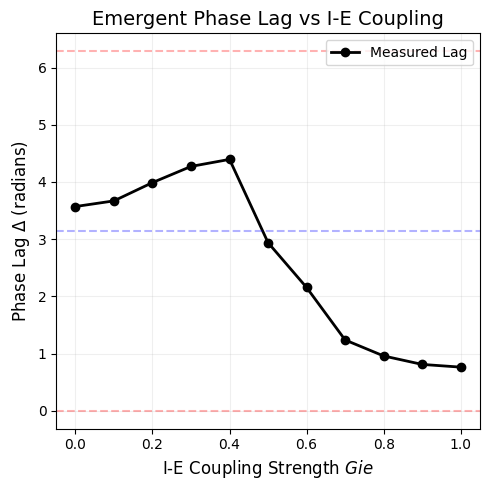

In [353]:
#this was run with defaultclock = 0.01ms, reset/threshold = +-500
#phase lag vs Gie
duration = 5000*ms
transient_time = 2000*ms
num_neurons = 2000 #*2
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
ax3=axes
Gie_range = np.arange(0.0, 1.1, 0.1)
gie_measured_lags = []
for Gie_val in Gie_range:
  rm1, rm2 = run_coupled_network(delay_val=6, Gee=0.1, Gie=Gie_val, duration=duration, Ne=num_neurons, Ni=num_neurons)
  current_lag = get_network_phase_lag(rm1, rm2, transient_time=transient_time)
  gie_measured_lags.append(current_lag)
  #print(f"Tested Delay: {d_val} ms | Resulting Phase Lag: {current_lag:.2f} ms")

ax3.plot(Gie_range, gie_measured_lags, 'o-', linewidth=2, color='k', label='Measured Lag')
ax3.axhline(np.pi, color='blue', linestyle='--', alpha=0.3)
ax3.axhline(2*np.pi, color='red', linestyle='--', alpha=0.3)
ax3.axhline(0, color='red', linestyle='--', alpha=0.3)
ax3.set_xlabel('I-E Coupling Strength $Gie$', fontsize=12)
ax3.set_ylabel('Phase Lag $\Delta$ (radians)', fontsize=12)
ax3.set_title('Emergent Phase Lag vs I-E Coupling', fontsize=14)
ax3.grid(True, alpha=0.2)
ax3.legend()

plt.tight_layout()
plt.show() 

The previous phase lag vs control parameter plots were not correctly scaled because the reset/threshold parameters were reduced by a factor of 10. The three plots above used the parameters as described in the paper with the brian2 defaultclock set to 0.01ms isntead of 0.1ms. This produces results similar to what Dumont and Gutkin reported. The issues with the raster plots as described previously do not occur. 

For synaptic delay, the plot still suggests that for short and long delays the network is in an in-phase oscillations regime. For a short delay range between 6-8ms there we are in a non-symmetric regime. Between 10ms-14ms the network produces anti-phase oscillations. DO THE RASTER PLOT STILL SHOW ISSUES? CHECK

These simulations still differ only use 2000 neurons rather than 5000. It could be that these simulations are not using enough neurons which results in slower convergence making the bifuraction more difficult to detect. We could not feasibly produce these graphs with larger populations.

For coupling strength parameters Gie and Gee the results are quite similar to what we saw previously.